In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammainc, gamma
from scipy.optimize import root
import matplotlib.colors as mcolors


# Physical constants
G = 6.67e-11        
c = 3e8             

# Lens masses (kg)
M_1 = 2e40
M_2 = 1.5e40
M_3 = 3e40

# Sérsic parameters
n = 4
b = 1.9992*n - 0.3271
r_e = 3.086e21  # effective radius (~100 kpc)

# Lens distances (~1 Gpc)
D_d_1 = D_d_2 = D_d_3 = 1.0e25
# Source distances
D_s_1, D_s_2, D_s_3 = 2.0e25, 2.2e25, 1.8e25
# Lens → source distances
D_ds_1 = D_s_1 - D_d_1
D_ds_2 = D_s_2 - D_d_2
D_ds_3 = D_s_3 - D_d_3

# Critical surface densities
Sigma_crit_1 = (c**2 / (4*np.pi*G)) * (D_s_1 / (D_d_1 * D_ds_1))
Sigma_crit_2 = (c**2 / (4*np.pi*G)) * (D_s_2 / (D_d_2 * D_ds_2))
Sigma_crit_3 = (c**2 / (4*np.pi*G)) * (D_s_3 / (D_d_3 * D_ds_3))

# Surface densities at r_e
Sigma_e_1 = M_1 / (2*np.pi*r_e**2)
Sigma_e_2 = M_2 / (2*np.pi*r_e**2)
Sigma_e_3 = M_3 / (2*np.pi*r_e**2)

# Convergences
kappa_e_1 = Sigma_e_1 / Sigma_crit_1
kappa_e_2 = Sigma_e_2 / Sigma_crit_2
kappa_e_3 = Sigma_e_3 / Sigma_crit_3

# Deflection scales
alpha_e_1 = n * r_e * kappa_e_1 * (b**(-2*n)) * np.exp(b) * gamma(2*n)
alpha_e_2 = n * r_e * kappa_e_2 * (b**(-2*n)) * np.exp(b) * gamma(2*n)
alpha_e_3 = n * r_e * kappa_e_3 * (b**(-2*n)) * np.exp(b) * gamma(2*n)

# Einstein radii
θ_E_1 = np.sqrt((4*G*M_1)/(c**2) * D_ds_1/(D_d_1*D_s_1))
θ_E_2 = np.sqrt((4*G*M_2)/(c**2) * D_ds_2/(D_d_2*D_s_2))
θ_E_3 = np.sqrt((4*G*M_3)/(c**2) * D_ds_3/(D_d_3*D_s_3))

# Source and lens positions

β_list_1 = [
    [0, 0],
    [0.5*θ_E_1, 0.5*θ_E_1],
    [-θ_E_1, θ_E_1],         
    [1.5*θ_E_1, -0.5*θ_E_1],
    [-2*θ_E_1, -θ_E_1]
]

β_list_2 = [
    [2*θ_E_1, -θ_E_1],
    [-3*θ_E_1, 0.5*θ_E_1],
    [0.25*θ_E_1, -1.5*θ_E_1], 
    [1.2*θ_E_1, 1.8*θ_E_1],
    [-0.7*θ_E_1, 2*θ_E_1]
]

O1_list = [
    [0, 0],
    [0.5*θ_E_1, -0.5*θ_E_1],   
    [-θ_E_1, 0],
    [0, 1.2*θ_E_1]
]

O2_list = [
    [2*θ_E_1, 0],
    [1.5*θ_E_1, 1.5*θ_E_1],    
    [-2*θ_E_1, 1*θ_E_1],
    [2.5*θ_E_1, -1.5*θ_E_1]
]

O3_list = [
    [-1.5*θ_E_1, 1.5*θ_E_1],
    [-2*θ_E_1, -1*θ_E_1],      
    [1*θ_E_1, -2*θ_E_1],
    [-1*θ_E_1, 2.5*θ_E_1]
]


In [7]:
β_1 = np.array(β_list_1[2])
β_2 = np.array(β_list_2[2])
O_1 = np.array(O1_list[1])
O_2 = np.array(O2_list[1])
O_3 = np.array(O3_list[1])


# Sérsic deflection (scaled to radians)

def sersic_deflection(theta, O, alpha_e, D_d):
    r_vec = theta - O
    r_ang = np.linalg.norm(r_vec)
    if r_ang == 0:
        return np.array([0.0, 0.0])
    r = D_d * r_ang
    x = (r / r_e)**(1/n)
    x = max(x, 1e-12)
    alpha_mag = 2 * alpha_e * x**(-n) * (1 - gammainc(2*n, b*x))
    alpha_vec = alpha_mag * r_vec / r_ang
    return alpha_vec / D_d  # convert deflection to angular units

def total_deflection(theta):
    return (sersic_deflection(theta, O_1, alpha_e_1, D_d_1) +
            sersic_deflection(theta, O_2, alpha_e_2, D_d_2) +
            sersic_deflection(theta, O_3, alpha_e_3, D_d_3))

def lens_equation(theta, beta):
    theta = np.array(theta)
    return theta - total_deflection(theta) - beta


# Image finder

def find_images(beta, n_guesses=200, perturb=3*θ_E_1, duplicate_tol=0.000004):
    beta = np.array(beta)
    solutions = []
    guesses = beta + np.random.uniform(-perturb, perturb, size=(n_guesses, 2))
    for g in guesses:
        sol = root(lens_equation, g, args=(beta,))
        if sol.success:
            θ = sol.x
            if not any(np.linalg.norm(θ - s) < duplicate_tol for s in solutions):
                solutions.append(θ)
    solutions.sort(key=lambda θ: np.linalg.norm(θ - beta))
    return solutions

images_1 = find_images(β_1)
images_2 = find_images(β_2)


# Magnifications

def magnification(theta, beta):
    eps = 1e-8
    dtheta_x = np.array([eps, 0])
    dtheta_y = np.array([0, eps])
    beta_x1 = lens_equation(theta + dtheta_x, beta)
    beta_x2 = lens_equation(theta - dtheta_x, beta)
    beta_y1 = lens_equation(theta + dtheta_y, beta)
    beta_y2 = lens_equation(theta - dtheta_y, beta)
    dβ_dx = (beta_x1 - beta_x2) / (2 * eps)
    dβ_dy = (beta_y1 - beta_y2) / (2 * eps)
    J = np.array([[dβ_dx[0], dβ_dy[0]], [dβ_dx[1], dβ_dy[1]]])
    detJ = np.linalg.det(J)
    return 1 / abs(detJ)

mu_1 = [magnification(θ, β_1) for θ in images_1]
mu_2 = [magnification(θ, β_2) for θ in images_2]


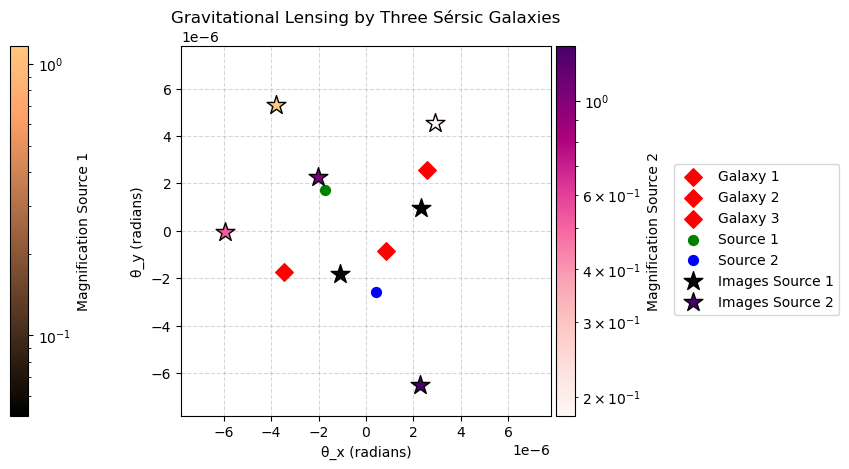

In [8]:
# Plotting

fig, ax = plt.subplots()
ax.set_aspect('equal')

# Plot galaxies first
ax.scatter(O_1[0], O_1[1], color='red', s=80, marker='D', zorder=5, label='Galaxy 1')
ax.scatter(O_2[0], O_2[1], color='red', s=80, marker='D', zorder=5, label='Galaxy 2')
ax.scatter(O_3[0], O_3[1], color='red', s=80, marker='D', zorder=5, label='Galaxy 3')

# Plot sources
ax.scatter(β_1[0], β_1[1], color='green', s=50, zorder=6, label='Source 1')
ax.scatter(β_2[0], β_2[1], color='blue', s=50, zorder=6, label='Source 2')

# Combine all positions to determine plot limits
all_positions = np.vstack([images_1, images_2, [O_1, O_2, O_3], [β_1, β_2]])
max_range = np.max(np.abs(all_positions)) * 1.2
ax.set_xlim(-max_range, max_range)
ax.set_ylim(-max_range, max_range)

# Colormaps
cmap1 = plt.cm.copper
cmap2 = plt.cm.RdPu
norm1 = mcolors.LogNorm(vmin=max(min(mu_1), 1e-3), vmax=max(mu_1))
norm2 = mcolors.LogNorm(vmin=max(min(mu_2), 1e-3), vmax=max(mu_2))

# Plot images of source 1
for i, θ in enumerate(images_1):
    ax.scatter(θ[0], θ[1], marker='*', s=200, color=cmap1(norm1(mu_1[i])),
               edgecolor='black', zorder=7, label='Images Source 1' if i==0 else '')

# Plot images of source 2
for i, θ in enumerate(images_2):
    ax.scatter(θ[0], θ[1], marker='*', s=200, color=cmap2(norm2(mu_2[i])),
               edgecolor='black', zorder=7, label='Images Source 2' if i==0 else '')

# Colorbars
sm1 = plt.cm.ScalarMappable(norm=norm1, cmap=cmap1)
cbar1 = plt.colorbar(sm1, ax=ax, fraction=0.046, pad=-1.2)
cbar1.set_label("Magnification Source 1")

sm2 = plt.cm.ScalarMappable(norm=norm2, cmap=cmap2)
cbar2 = plt.colorbar(sm2, ax=ax, fraction=0.046, pad=0.005)
cbar2.set_label("Magnification Source 2")

ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlabel("θ_x (radians)")
ax.set_ylabel("θ_y (radians)")
ax.set_title("Gravitational Lensing by Three Sérsic Galaxies")
ax.legend(loc='upper right', bbox_to_anchor=(1.8, 0.7))

plt.show()
